In [8]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

In [4]:
# Load training data
try:
    train_df = pd.read_csv('train (2).csv', on_bad_lines='skip',sep=';')
    print("Train dataset loaded successfully.")
except Exception as e:
    print(f"Error loading train dataset: {e}")

# Load evaluation data
try:
    eval_df = pd.read_csv('evaluation.csv', on_bad_lines='skip',sep=';')
    print("Evaluation dataset loaded successfully.")
except Exception as e:
    print(f"Error loading evaluation dataset: {e}")

# Load test data
try:
    test_df = pd.read_csv('test (1).csv', on_bad_lines='skip',sep=';')
    print("Test dataset loaded successfully.")
except Exception as e:
    print(f"Error loading test dataset: {e}")

# Display basic information about each dataset
print("Train Dataset Info:")
print(train_df.info())
print(train_df.head())

print("\nEvaluation Dataset Info:")
print(eval_df.info())
print(eval_df.head())

print("\nTest Dataset Info:")
print(test_df.info())
print(test_df.head())

Train dataset loaded successfully.
Evaluation dataset loaded successfully.
Test dataset loaded successfully.
Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24353 entries, 0 to 24352
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  24353 non-null  int64 
 1   title       24353 non-null  object
 2   text        24353 non-null  object
 3   label       24353 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 761.2+ KB
None
   Unnamed: 0                                              title  \
0           0  Palestinians switch off Christmas lights in Be...   
1           1  China says Trump call with Taiwan president wo...   
2           2   FAIL! The Trump Organization’s Credit Score W...   
3           3  Zimbabwe military chief's China trip was norma...   
4           4  THE MOST UNCOURAGEOUS PRESIDENT EVER Receives ...   

                                                text  lab

In [6]:
# Quick sanity check of labels
print(f"Dataset shape: {train_df.shape}")
print(f"\nLabel distribution:")
print(train_df['label'].value_counts())

# Sample titles for each label
print("\n=== SAMPLE TITLES FOR EACH LABEL ===")
print("\nLabel 1 (allegedly fake):")
for title in train_df[train_df['label'] == 1]['title'].head(5):
    print(f"  - {title}")

print("\nLabel 0 (allegedly real/other):")
for title in train_df[train_df['label'] == 0]['title'].head(5):
    print(f"  - {title}")

# Check if Reuters is always one label
print("\n=== CHECKING SOURCE PATTERNS ===")
print("Does 'Reuters' appear in text?")
print("Label 1:", train_df[train_df['label'] == 1]['text'].str.contains('Reuters').mean())
print("Label 0:", train_df[train_df['label'] == 0]['text'].str.contains('Reuters').mean())

Dataset shape: (24353, 5)

Label distribution:
label
1    13246
0    11107
Name: count, dtype: int64

=== SAMPLE TITLES FOR EACH LABEL ===

Label 1 (allegedly fake):
  - Palestinians switch off Christmas lights in Bethlehem in anti-Trump protest
  - China says Trump call with Taiwan president won't change island's status
  - Zimbabwe military chief's China trip was normal visit, Beijing says
  - Suspected Boko Haram suicide bombers kill at least 13 in Nigeria: officials
  - Senate Democrats ask Trump attorney general pick to recuse himself from Russia probes

Label 0 (allegedly real/other):
  -  FAIL! The Trump Organization’s Credit Score Will Make You Laugh
  - THE MOST UNCOURAGEOUS PRESIDENT EVER Receives A Courage Award…Proceeds To Whine About Current President
  - WATCH: John Oliver Presents GOP Debates As ‘Clowntown F*ck-the-World Sh*tshow 2016’
  -  Trump HUMILIATES Republicans In Latest Hissy Fit After Siding With Democrats On Debt Ceiling
  - MACY’S GETS THE BOOT FROM LOYAL CUS

Note: Most likely 1=Real and 0=Fake

In [9]:
# ====================
# 1. SETUP LABEL INTERPRETATION
# ====================
print("=== LABEL INTERPRETATION ===")
print("1 = Real (Reuters articles)")
print("0 = Fake (non-Reuters/sensational)")
print("\nDataset sizes:")
print(f"Train: {len(train_df)} samples")
print(f"Eval (validation): {len(eval_df)} samples")
print(f"Test: {len(test_df)} samples")

# Check label distribution in each set
print("\n=== LABEL DISTRIBUTIONS ===")
for name, df in [("Train", train_df), ("Eval", eval_df), ("Test", test_df)]:
    if 'label' in df.columns:
        counts = df['label'].value_counts()
        print(f"\n{name} set:")
        print(f"  Real (1): {counts.get(1, 0)} ({counts.get(1, 0)/len(df):.1%})")
        print(f"  Fake (0): {counts.get(0, 0)} ({counts.get(0, 0)/len(df):.1%})")

# Verify with samples
print("\n=== SAMPLE VERIFICATION ===")
print("Real articles (label=1) from train:")
for title in train_df[train_df['label'] == 1]['title'].head(2):
    print(f"  ✓ {title}")

print("\nFake articles (label=0) from train:")
for title in train_df[train_df['label'] == 0]['title'].head(2):
    print(f"  ✗ {title}")

=== LABEL INTERPRETATION ===
1 = Real (Reuters articles)
0 = Fake (non-Reuters/sensational)

Dataset sizes:
Train: 24353 samples
Eval (validation): 8117 samples
Test: 8117 samples

=== LABEL DISTRIBUTIONS ===

Train set:
  Real (1): 13246 (54.4%)
  Fake (0): 11107 (45.6%)

Eval set:
  Real (1): 4314 (53.1%)
  Fake (0): 3803 (46.9%)

Test set:
  Real (1): 4364 (53.8%)
  Fake (0): 3753 (46.2%)

=== SAMPLE VERIFICATION ===
Real articles (label=1) from train:
  ✓ Palestinians switch off Christmas lights in Bethlehem in anti-Trump protest
  ✓ China says Trump call with Taiwan president won't change island's status

Fake articles (label=0) from train:
  ✗  FAIL! The Trump Organization’s Credit Score Will Make You Laugh
  ✗ THE MOST UNCOURAGEOUS PRESIDENT EVER Receives A Courage Award…Proceeds To Whine About Current President


In [10]:
# ====================
# 2. PREPARE ALL DATASETS
# ====================
def prepare_dataset(df):
    """Prepare a single dataset"""
    df = df.copy()
    
    # Combine title and text
    if 'title' in df.columns and 'text' in df.columns:
        df['content'] = df['title'] + " " + df['text']
    elif 'content' in df.columns:
        pass  # Already has content
    else:
        raise ValueError("Dataset must have 'title' and 'text' or 'content' columns")
    
    # Optional text cleaning
    def clean_text(text):
        if pd.isna(text):
            return ""
        text = str(text)
        # Remove URLs
        text = re.sub(r'https?://\S+|www\.\S+', '', text)
        # Remove special characters but keep basic punctuation
        text = re.sub(r'[^\w\s.,!?-]', '', text)
        # Normalize whitespace
        text = re.sub(r'\s+', ' ', text)
        return text.strip()
    
    df['content'] = df['content'].apply(clean_text)
    return df

# Prepare all datasets
print("\nPreparing datasets...")
train_df = prepare_dataset(train_df)
eval_df = prepare_dataset(eval_df)
test_df = prepare_dataset(test_df)

print(f"\nContent length stats (train set):")
content_lengths = train_df['content'].str.len()
print(f"  Min: {content_lengths.min()} chars")
print(f"  Max: {content_lengths.max()} chars")
print(f"  Mean: {content_lengths.mean():.0f} chars")



Preparing datasets...

Content length stats (train set):
  Min: 0 chars
  Max: 48531 chars
  Mean: 2552 chars


In [11]:
# ====================
# 3. CREATE MODEL PIPELINE
# ====================
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),  # Unigrams and bigrams
    stop_words='english',
    min_df=5,            # Ignore very rare terms
    max_df=0.7,          # Ignore very common terms
    sublinear_tf=True,   # Use log(1 + tf) instead of raw counts
    analyzer='word'      # Word-level features
)

# Note: LogisticRegression predicts class 1 when probability > 0.5
# So it will predict "Real" when it thinks P(Real) > 0.5
model = Pipeline([
    ('tfidf', tfidf),
    ('clf', LogisticRegression(
        max_iter=1000,
        #class_weight='balanced',  # Adjust for class imbalance
        random_state=42,
        C=1.0,                    # Regularization strength
        solver='liblinear'        # Good for text classification
    ))
])

In [12]:
# ====================
# 4. TRAIN ON TRAIN SET
# ====================
print("\n" + "="*60)
print("TRAINING PHASE")
print("="*60)

X_train = train_df['content']
y_train = train_df['label']  # 1=Real, 0=Fake

print(f"Training on {len(X_train)} samples...")
model.fit(X_train, y_train)
print("Training complete!")


TRAINING PHASE
Training on 24353 samples...
Training complete!


In [37]:
# Test with the full pipeline 
test_text = ["Why John McCain Will Never Vote to Repeal and Replace Obamacare "]

# Use the model pipeline directly
prob = model.predict_proba(test_text)[0]
prediction = model.predict(test_text)[0]

print(f"Title: {test_text[0]}")
print(f"Prediction: {'REAL' if prediction == 1 else 'FAKE'}")
print(f"Probability Real: {prob[1]:.3f}")
print(f"Probability Fake: {prob[0]:.3f}")

Title: Why John McCain Will Never Vote to Repeal and Replace Obamacare 
Prediction: FAKE
Probability Real: 0.362
Probability Fake: 0.638



EVALUATION PHASE (Eval/Validation Set)
Evaluation on 8117 samples:
Accuracy: 0.976
ROC-AUC (Real vs Fake): 0.996

Classification Report (Eval set):
              precision    recall  f1-score   support

    Fake (0)      0.972     0.978     0.975      3803
    Real (1)      0.981     0.975     0.978      4314

    accuracy                          0.976      8117
   macro avg      0.976     0.976     0.976      8117
weighted avg      0.976     0.976     0.976      8117



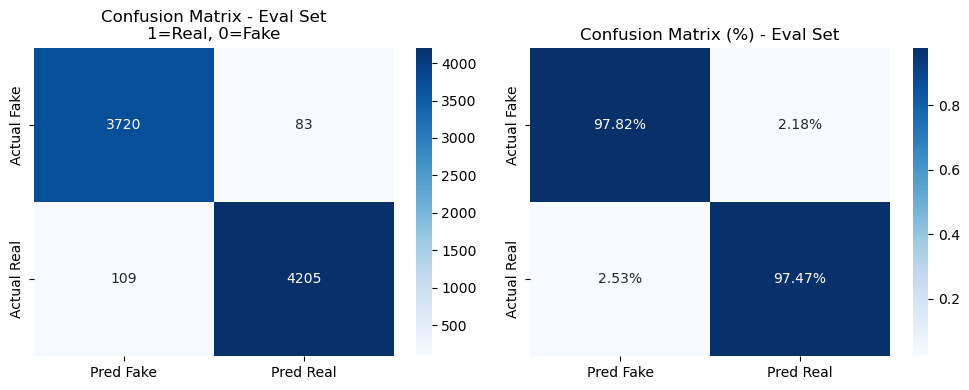

In [13]:
# ====================
# 5. EVALUATE ON EVAL/VALIDATION SET
# ====================
print("\n" + "="*60)
print("EVALUATION PHASE (Eval/Validation Set)")
print("="*60)

X_eval = eval_df['content']
y_eval = eval_df['label']

y_pred_eval = model.predict(X_eval)
y_proba_eval = model.predict_proba(X_eval)

# model.predict_proba returns [P(class 0), P(class 1)]
prob_fake_eval = y_proba_eval[:, 0]  # Probability of Fake
prob_real_eval = y_proba_eval[:, 1]  # Probability of Real

print(f"Evaluation on {len(X_eval)} samples:")
print(f"Accuracy: {accuracy_score(y_eval, y_pred_eval):.3f}")
print(f"ROC-AUC (Real vs Fake): {roc_auc_score(y_eval, prob_real_eval):.3f}")

print("\nClassification Report (Eval set):")
print(classification_report(y_eval, y_pred_eval, 
                          target_names=['Fake (0)', 'Real (1)'],
                          digits=3))

# Confusion Matrix for Eval set
cm_eval = confusion_matrix(y_eval, y_pred_eval)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.heatmap(cm_eval, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Fake', 'Pred Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.title('Confusion Matrix - Eval Set\n1=Real, 0=Fake')

# Add percentages
plt.subplot(1, 2, 2)
cm_percent = cm_eval / cm_eval.sum(axis=1, keepdims=True)
sns.heatmap(cm_percent, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Pred Fake', 'Pred Real'],
            yticklabels=['Actual Fake', 'Actual Real'])
plt.title('Confusion Matrix (%) - Eval Set')

plt.tight_layout()
plt.show()


TEST PHASE (Final Test Set)
Testing on 8117 samples:
Accuracy: 0.981
ROC-AUC: 0.997

Classification Report (Test set):
              precision    recall  f1-score   support

    Fake (0)      0.977     0.981     0.979      3753
    Real (1)      0.984     0.980     0.982      4364

    accuracy                          0.981      8117
   macro avg      0.980     0.981     0.981      8117
weighted avg      0.981     0.981     0.981      8117



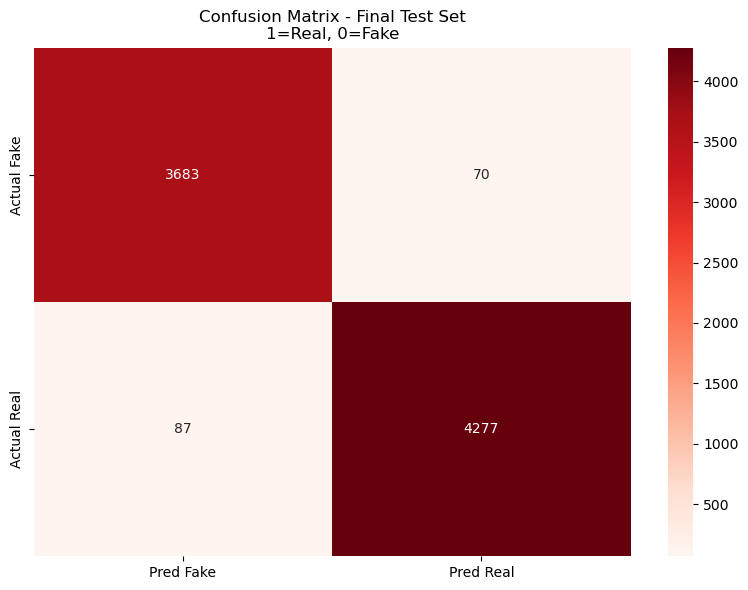

In [29]:

# ====================
# 6. TEST ON TEST SET
# ====================
print("\n" + "="*60)
print("TEST PHASE (Final Test Set)")
print("="*60)

if 'label' in test_df.columns:
    X_test = test_df['content']
    y_test = test_df['label']
    
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)
    prob_real_test = y_proba_test[:, 1]
    
    print(f"Testing on {len(X_test)} samples:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.3f}")
    print(f"ROC-AUC: {roc_auc_score(y_test, prob_real_test):.3f}")
    
    print("\nClassification Report (Test set):")
    print(classification_report(y_test, y_pred_test, 
                              target_names=['Fake (0)', 'Real (1)'],
                              digits=3))
    
    # Confusion Matrix for Test set
    cm_test = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Pred Fake', 'Pred Real'],
                yticklabels=['Actual Fake', 'Actual Real'])
    plt.title('Confusion Matrix - Final Test Set\n1=Real, 0=Fake')
    plt.tight_layout()
    plt.show()
    
    # Save predictions
    test_df['predicted_label'] = y_pred_test
    test_df['predicted_prob_real'] = prob_real_test
    test_df['predicted_prob_fake'] = y_proba_test[:, 0]
    
else:
    print("Test set doesn't have labels - making predictions only")
    X_test = test_df['content']
    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)
    
    test_df['predicted_label'] = y_pred_test
    test_df['predicted_prob_real'] = y_proba_test[:, 1]
    test_df['predicted_prob_fake'] = y_proba_test[:, 0]

In [30]:
# ====================
# 7. MODEL INTERPRETATION
# ====================
print("\n" + "="*60)
print("MODEL INTERPRETATION")
print("="*60)

# Get feature names and coefficients
feature_names = model.named_steps['tfidf'].get_feature_names_out()
coefficients = model.named_steps['clf'].coef_[0]

print(f"Total features: {len(feature_names)}")

# Top predictors for REAL news (positive coefficients = predict Real)
real_indices = np.argsort(coefficients)[-15:]  # Top 15 for Real
print("\nTop words/phrases predicting REAL news (positive coefficients):")
for idx in real_indices[::-1]:  # Reverse to show highest first
    print(f"  '{feature_names[idx]}': {coefficients[idx]:.4f}")

# Top predictors for FAKE news (negative coefficients = predict Fake)
fake_indices = np.argsort(coefficients)[:15]  # Bottom 15 for Fake
print("\nTop words/phrases predicting FAKE news (negative coefficients):")
for idx in fake_indices:
    print(f"  '{feature_names[idx]}': {coefficients[idx]:.4f}")


MODEL INTERPRETATION
Total features: 8000

Top words/phrases predicting REAL news (positive coefficients):
  'reuters': 19.4076
  'washington reuters': 7.8062
  'trumps': 6.4409
  'president donald': 4.5551
  'wednesday': 4.1832
  'washington': 4.0242
  'reuters president': 3.8655
  'tuesday': 3.7224
  'thursday': 3.4359
  'said statement': 3.4286
  'monday': 3.3299
  'dont': 3.3076
  'friday': 3.1654
  'nov': 3.1164
  'minister': 3.0753

Top words/phrases predicting FAKE news (negative coefficients):
  'video': -8.5140
  'image': -6.0747
  'featured image': -5.6188
  'featured': -5.5931
  'just': -4.7712
  'read': -4.6268
  'gop': -4.2396
  'don': -4.1853
  'obama': -4.1266
  'doesn': -3.9400
  'didn': -3.8937
  'president trump': -3.8538
  'pic': -3.7491
  'america': -3.7022
  'pic twitter': -3.6572


In [31]:
# ====================
# 8. ERROR ANALYSIS
# ====================
print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)

if 'label' in eval_df.columns:
    # Get indices of errors in eval set
    eval_errors = eval_df[y_eval != y_pred_eval].copy()
    print(f"\nTotal errors in eval set: {len(eval_errors)}/{len(eval_df)} ({len(eval_errors)/len(eval_df):.1%})")
    
    # False Positives (Real labeled as Fake)
    fp_mask = (y_eval == 1) & (y_pred_eval == 0)
    false_positives = eval_df[fp_mask]
    print(f"False Positives (Real → Fake): {len(false_positives)}")
    
    # False Negatives (Fake labeled as Real)
    fn_mask = (y_eval == 0) & (y_pred_eval == 1)
    false_negatives = eval_df[fn_mask]
    print(f"False Negatives (Fake → Real): {len(false_negatives)}")
    
    # Analyze some errors
    if len(false_positives) > 0:
        print("\n=== FALSE POSITIVE EXAMPLES (Real news incorrectly labeled as Fake) ===")
        for idx, row in false_positives.head(3).iterrows():
            print(f"\nTitle: {row['title']}")
            print(f"True: Real, Predicted: Fake")
            print(f"Text preview: {row['text'][:150]}...")
    
    if len(false_negatives) > 0:
        print("\n=== FALSE NEGATIVE EXAMPLES (Fake news incorrectly labeled as Real) ===")
        for idx, row in false_negatives.head(3).iterrows():
            print(f"\nTitle: {row['title']}")
            print(f"True: Fake, Predicted: Real")
            print(f"Text preview: {row['text'][:150]}...")


ERROR ANALYSIS

Total errors in eval set: 192/8117 (2.4%)
False Positives (Real → Fake): 109
False Negatives (Fake → Real): 83

=== FALSE POSITIVE EXAMPLES (Real news incorrectly labeled as Fake) ===

Title: baier indictment likely in fbi investigation of clinton foundation
True: Real, Predicted: Fake
Text preview: go to article 
president barack obama has been campaigning hard for the woman who is supposedly going to extend his legacy four more years the only pr...

Title: american woman in bikini desecrates french catacombs for her female indiana jones brand
True: Real, Predicted: Fake
Text preview: why you should become a minimalist why you should become a minimalist february    comments lifestyle 
the most abused word in the english language is ...

Title: dow higher as boeing gains offset apples fall
True: Real, Predicted: Fake
Text preview: bellwether trump kippas outselling hillary yarmulkes company sees preference as early exit poll of orthodox jews published  mins ago print 
